Team : Anna Moy & Natalie Kalukeerthie

The dataset is the attendance for 18 Southern Women at 14 social events.  The first step is to load the data into a bipartite graph and graph it to see which events the women attended.

['Evelyn Jefferson', 'Laura Mandeville', 'Theresa Anderson', 'Brenda Rogers', 'Charlotte McDowd', 'Frances Anderson', 'Eleanor Nye', 'Pearl Oglethorpe', 'Ruth DeSand', 'Verne Sanderson', 'Myra Liddel', 'Katherina Rogers', 'Sylvia Avondale', 'Nora Fayette', 'Helen Lloyd', 'Dorothy Murchison', 'Olivia Carleton', 'Flora Price']
['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11', 'E12', 'E13', 'E14']


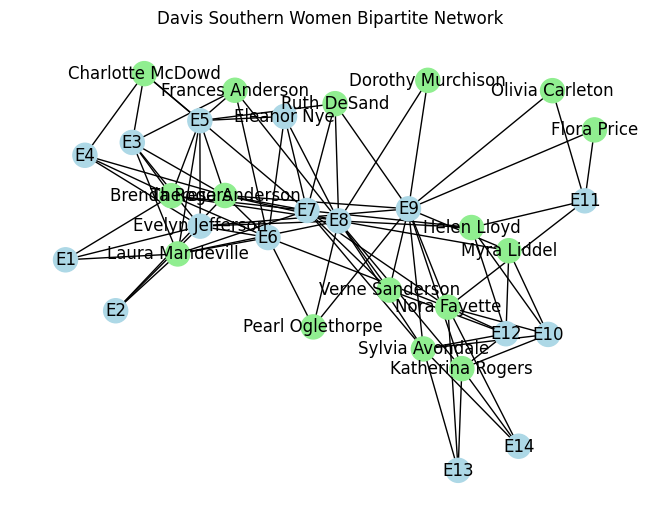

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms import bipartite, community

# Load the bipartite graph
G = nx.davis_southern_women_graph()


# Draw the bipartite graph
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color=["lightblue" if n[0] == "E" else "lightgreen" for n in G.nodes()])
plt.title("Davis Southern Women Bipartite Network")
plt.show()

Next, we separated the nodes out for both the women and events and charted the bipartite graph for the women. This allows us to see which womens are connected to each other based on the events they attended. Based on the chart it seems like many of the women were connected to each other.

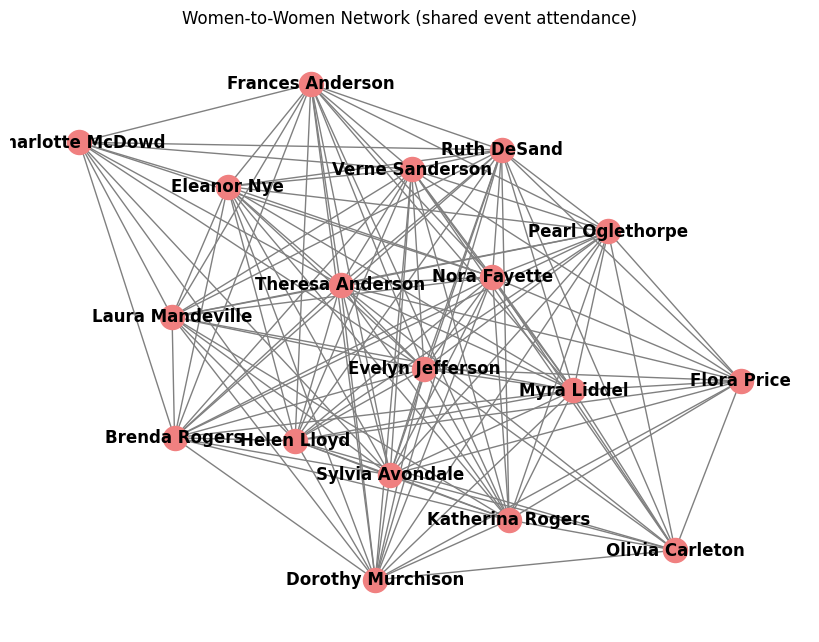

In [ ]:
# Separate nodes into women and events
women = [n for n, d in G.nodes(data=True) if d['bipartite'] == 0]
events = [n for n in G.nodes() if n not in women]

# Create the projected graph: women who attended the same events
W = bipartite.projected_graph(G, women)

# Graph for women
plt.figure(figsize=(8, 6))
nx.draw(W, with_labels=True, node_color='lightcoral', edge_color='gray', font_weight='bold')
plt.title("Women-to-Women Network (shared event attendance)")
plt.show()


We conducted a degree of centrality to find who are the top 10 most connected women in the event. The degree of centrality for 7 of the womens came back as 1 which indicates they are socially connected and shared an event with each woman. This shows these 7 women may have attended every event.

*   Degree of centrality - measures the importance in a network. A node with a high degree of centrality means they have the most connection. The highest degree of centrality is 1.



In [ ]:
# Degree centrality (who has most connections)
deg_cent = nx.degree_centrality(W)
top10 = sorted(deg_cent.items(), key=lambda x: -x[1])[:10]

print("Top 3 most connections:")
for name, score in top10:
    print(f"{name}: {score:.10f}")


Top 3 most connections:
Evelyn Jefferson: 1.0000000000
Theresa Anderson: 1.0000000000
Ruth DeSand: 1.0000000000
Verne Sanderson: 1.0000000000
Sylvia Avondale: 1.0000000000
Nora Fayette: 1.0000000000
Helen Lloyd: 1.0000000000
Pearl Oglethorpe: 0.9411764706
Myra Liddel: 0.9411764706
Katherina Rogers: 0.9411764706


With 7 out of the 18 women attending events together we took a look to see if there were cluster of them attending events together.

The results indicate the women in first group attends the same event a lot which indicates they might be good friends and attend events together.

The second group consists of women who have overlapping attendance at certain events, suggesting that they may share common interests or social ties that connect them. The attendance in certain events indicate they might be part of a friend group or a social circle centered around specific types of events.



In [ ]:
# Detect communities (groups of women who mostly attend events together)
communities = community.greedy_modularity_communities(W)

print("\nPredicted Women who attend the most event together:")
for i, group in enumerate(communities, 1):
    print(f"Group {i}: {sorted(group)}")


Predicted Women who attend the most event together:
Group 1: ['Dorothy Murchison', 'Evelyn Jefferson', 'Flora Price', 'Helen Lloyd', 'Katherina Rogers', 'Myra Liddel', 'Nora Fayette', 'Olivia Carleton', 'Pearl Oglethorpe', 'Ruth DeSand', 'Sylvia Avondale', 'Theresa Anderson']
Group 2: ['Brenda Rogers', 'Charlotte McDowd', 'Eleanor Nye', 'Frances Anderson', 'Laura Mandeville', 'Verne Sanderson']


Next, we aim to identify potential new friendships or connections among these women. Many pairs have a Jaccard similarity score of 0.688, which exceeds 50%, indicating a strong overlap in their social circles. This suggests that they are highly likely to form connections with each other over time.



*   Jaccard Coefficent - a measure of similarity between two nodes. The similarity score ranges from 0 to 1 and 0 means they have no common neighbors



In [ ]:
# Predict possible new friendships using Jaccard coefficient
preds = nx.jaccard_coefficient(W)

print("\nTop 15 Predicted Future Friends:")
for u, v, score in sorted(preds, key=lambda x: -x[2])[:15]:
    print(f"{u} - {v}: {score:.3f}")



Top 15 Predicted Future Friends:
Katherina Rogers - Charlotte McDowd: 0.688
Olivia Carleton - Frances Anderson: 0.688
Olivia Carleton - Eleanor Nye: 0.688
Olivia Carleton - Laura Mandeville: 0.688
Olivia Carleton - Brenda Rogers: 0.688
Frances Anderson - Flora Price: 0.688
Dorothy Murchison - Charlotte McDowd: 0.688
Charlotte McDowd - Myra Liddel: 0.688
Charlotte McDowd - Pearl Oglethorpe: 0.688
Eleanor Nye - Flora Price: 0.688
Flora Price - Brenda Rogers: 0.688
Flora Price - Laura Mandeville: 0.688
Olivia Carleton - Charlotte McDowd: 0.438
Charlotte McDowd - Flora Price: 0.438


We also conducted a centrality of degree for the events and the results show all 18 women attend the events for six to nine. Which indicates these events were most popular for women to attend to.

In [ ]:
# Centrality Events (which events were most attended by overlapping groups?)
centrality_events = nx.degree_centrality(E)

top_events = sorted(centrality_events.items(), key=lambda x: -x[1])[:5]
print("\nTop 5 Events")
for event, score in top_events:
    print(f"{event}: {score:.2f}")


Top 5 Events
E6: 1.00
E7: 1.00
E8: 1.00
E9: 1.00
E1: 0.62


We conducted a community modularity also for the events and we have two different groups as a result. The first group of events indicate a certain group of women would attend the events. The second group of women were attending by different groups of women.

In [ ]:
# Event Community Detection
event_communities = community.greedy_modularity_communities(E)
print("\nEvent Clusters based on the attendees:")
for i, group in enumerate(event_communities, 1):
    print(f"Cluster {i}: {sorted(group)}")


Event Clusters based on the attendees:
Cluster 1: ['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7']
Cluster 2: ['E10', 'E11', 'E12', 'E13', 'E14', 'E8', 'E9']


We can infer that the network of women is divided into two main social groups based on shared event attendance. The first group of women appears to have attended many events together and particularly those in Event Cluster 1 (E1 to E7). The second group of women seems to overlap in their connections but attend a different set of events, mainly those in Event Cluster 2 (E8 to E11 and beyond).

Despite this division, there is strong evidence of potential future connections between the two groups. Many pairs of women across groups have a high Jaccard coefficient score (e.g., 0.688), indicating significant overlap in their social circles. This suggests that even if they are not directly connected now, they are likely to become friends in the future due to shared connections and event participation.

Additionally, Events E6 to E9 stand out as the most central and popular, with a centrality score of 1.00, meaning all women attended these events. These events likely served as key social hubs, where both groups interacted and possibly began forming cross-group connections.